In [6]:
from loader import load_features, preprocess_features
from specral_privacy_pipeline import DPLaplacianEigenmaps, PPSPLaplacianNoise, SpectralGapNoise, EmbeddingPerturbation
from ml_pipeline import run_classification, run_cv_inference_attack, display_classification_results

# Loading Feature Set & Preprocessing

In [7]:
x, y, target_names = load_features(
    file_path="features_raw_0_overlap.csv",
    meta_cols=['file_id', 'fault_size', 'load'],
    label_col='label'
)
X_scaled = preprocess_features(x)

In [8]:
import numpy as np

sensitive_class_name = "B"
sensitive_label = np.where(target_names == sensitive_class_name)[0][0]

In [9]:
# eps = 1.0
# records = {
#     "Noisy Embedding": [],
#     "Noisy Projection": []
# }

# model = DPLaplacianEigenmaps(
#     n_neighbors=10,
#     n_components=4,
#     noise_mechanism=SpectralGapNoise(epsilon=eps)
# )

# results = model.fit_transform(X_scaled)

# for title, X in {"Raw Features": X_scaled, "Clean Embedding": results["embedding_clean"]}.items():
#     print(f"=== Stage: {title} ===")
#     display_classification_results(run_classification(X, y, target_names))
#     run_cv_inference_attack(X, y, sensitive_class=sensitive_label)

# stages = {
#     "Noisy Embedding" : results["embedding_noisy"],
# }

# for title, X in stages.items():
#     print(f"=== Stage: {title} - ε={eps} ===")
#     clf_res = run_classification(X, y, target_names)
#     display_classification_results(clf_res)

#     atk_df  = run_cv_inference_attack(X, y, sensitive_class=sensitive_label, verbose=True)

#     macro_f1 = clf_res["Random Forest"]["macro_f1"]
#     adv_auc  = float(atk_df.loc["Logistic Regression (LR)", "Adv AUC"])
#     priv_gain = float(atk_df.loc["Logistic Regression (LR)", "Privacy Gain"])

#     records[title].append({
#         "epsilon"   : eps,
#         "macro_f1"  : macro_f1,
#         "adv_auc"   : adv_auc,
#         "priv_gain" : priv_gain,
#     })

In [10]:
import matplotlib.pyplot as plt

epsilons = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

records = {"Noisy Embedding": [], "Noisy Projection": []}

for eps in epsilons:
    model = DPLaplacianEigenmaps(
        n_neighbors=10,
        n_components=4,
        noise_mechanism=SpectralGapNoise(epsilon=eps)
    )
    results = model.fit_transform(X_scaled)

    if eps == epsilons[0]:
        for title, X in {"Raw Features": X_scaled, "Clean Embedding": results["embedding_clean"]}.items():
            print(f"=== Stage: {title} ===")
            display_classification_results(run_classification(X, y, target_names))
            run_cv_inference_attack(X, y, sensitive_class=sensitive_label)

    stages = {
        "Noisy Embedding" : results["embedding_noisy"],
    }
    for title, X in stages.items():
        print(f"=== Stage: {title} - ε={eps} ===")
        clf_res = run_classification(X, y, target_names)
        display_classification_results(clf_res)

        atk_df  = run_cv_inference_attack(X, y, sensitive_class=sensitive_label, verbose=True)

        macro_f1 = clf_res["Random Forest"]["macro_f1"]
        adv_auc  = float(atk_df.loc["Logistic Regression (LR)", "Adv AUC"])
        priv_gain = float(atk_df.loc["Logistic Regression (LR)", "Privacy Gain"])



        records[title].append({
            "epsilon"   : eps,
            "macro_f1"  : macro_f1,
            "adv_auc"   : adv_auc,
            "priv_gain" : priv_gain,
        })



=== Stage: Raw Features ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Random Forest,0.994,0.996,0.994,0.995
2,SVM,0.981,0.982,0.981,0.982
4,Decision Tree,0.973,0.974,0.975,0.974
3,KNN,0.962,0.962,0.967,0.964
0,Logistic Regression,0.954,0.963,0.952,0.957



  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.9951 -0.2111 0.9773 0.9990  ✗ leaked

=== Stage: Clean Embedding ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,KNN,0.933,0.938,0.936,0.937
1,Random Forest,0.926,0.933,0.929,0.931
4,Decision Tree,0.902,0.910,0.907,0.909
2,SVM,0.740,0.780,0.741,0.723
0,Logistic Regression,0.421,0.599,0.298,0.223



  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.7299 +0.0541 -0.2503 0.4611  ✓ private

=== Stage: Noisy Embedding - ε=0.1 ===


...


  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.5354 +0.2485 -1.1505 0.5873  ✓ private

=== Stage: Noisy Embedding - ε=5.0 ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,KNN,0.921,0.927,0.925,0.926
1,Random Forest,0.917,0.924,0.920,0.922
4,Decision Tree,0.890,0.898,0.894,0.896
2,SVM,0.758,0.774,0.774,0.762
0,Logistic Regression,0.710,0.752,0.712,0.721



  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.5361 +0.2479 -1.1473 0.5871  ✓ private

=== Stage: Noisy Embedding - ε=10.0 ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Random Forest,0.926,0.933,0.929,0.931
3,KNN,0.918,0.925,0.922,0.923
4,Decision Tree,0.906,0.914,0.908,0.911
2,SVM,0.751,0.769,0.762,0.751
0,Logistic Regression,0.651,0.726,0.629,0.641



  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.5514 +0.2326 -1.0766 0.5836  ✓ private



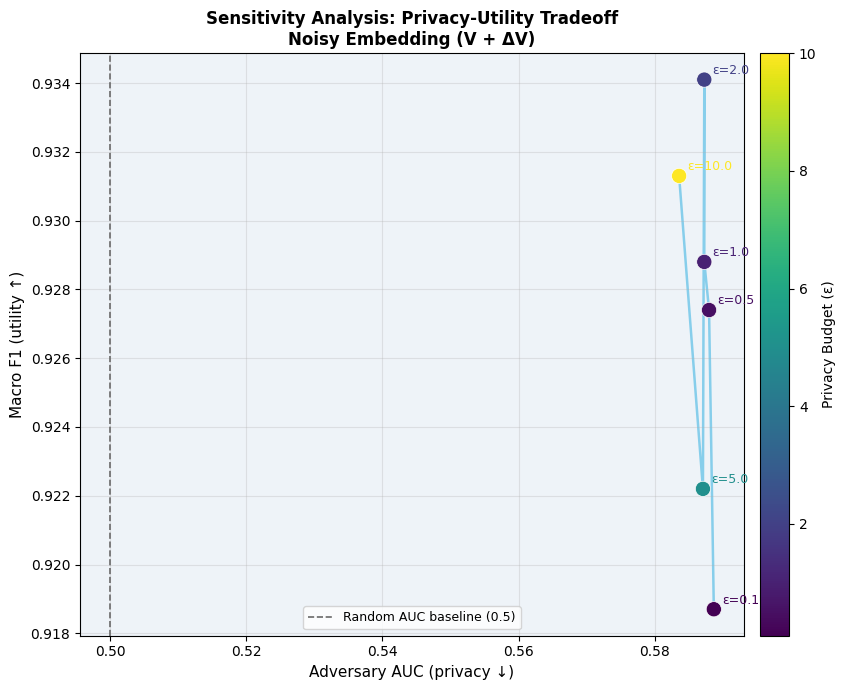

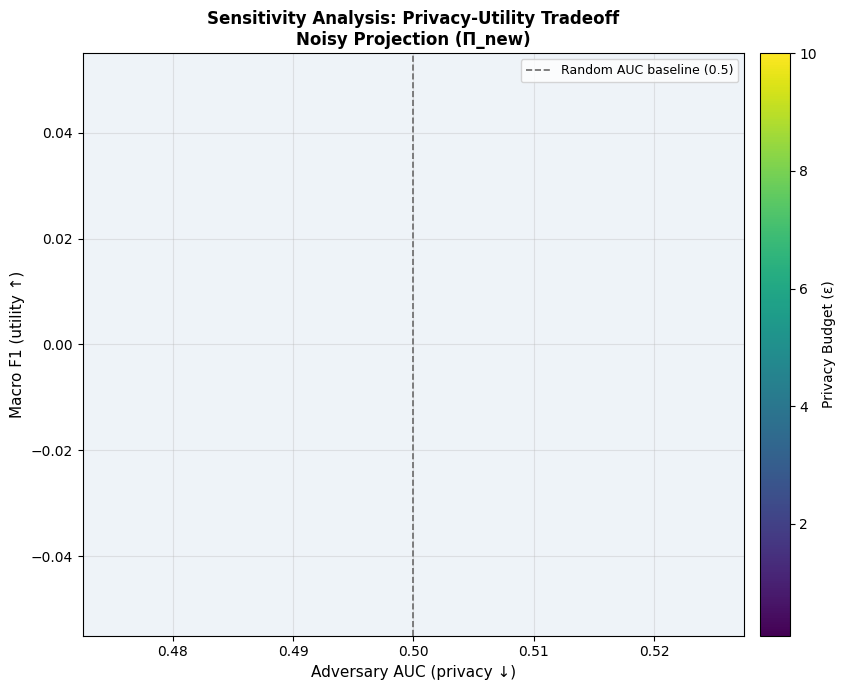

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

cmap    = cm.viridis
eps_arr = np.array(epsilons)
norm    = mcolors.Normalize(vmin=eps_arr.min(), vmax=eps_arr.max())

stage_titles = {
    "Noisy Embedding" : "Noisy Embedding (V + ΔV)",
    "Noisy Projection": "Noisy Projection (Π_new)",
}

baseline = max((y == sensitive_label).mean(), 1 - (y == sensitive_label).mean())

for stage, recs in records.items():
    adv_aucs = [r["adv_auc"]  for r in recs]
    f1s      = [r["macro_f1"] for r in recs]
    eps_vals = [r["epsilon"]  for r in recs]
    colors   = [cmap(norm(e)) for e in eps_vals]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_facecolor("#EEF3F8")
    fig.patch.set_facecolor("white")

    ax.plot(adv_aucs, f1s, color="skyblue", linewidth=1.8, zorder=1)
    sc = ax.scatter(adv_aucs, f1s, c=eps_vals, cmap=cmap, norm=norm,
                    s=120, zorder=2, edgecolors="white", linewidths=0.5)

    for r, c in zip(recs, colors):
        ax.annotate(
            f"ε={r['epsilon']}",
            xy=(r["adv_auc"], r["macro_f1"]),
            xytext=(6, 4), textcoords="offset points",
            fontsize=9, color=c,
        )

    ax.axvline(0.5, color="dimgray", linestyle="--", linewidth=1.2,
               label="Random AUC baseline (0.5)")

    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("Privacy Budget (ε)", fontsize=10)

    ax.set_xlabel("Adversary AUC (privacy ↓)", fontsize=11)
    ax.set_ylabel("Macro F1 (utility ↑)", fontsize=11)
    ax.set_title(
        f"Sensitivity Analysis: Privacy-Utility Tradeoff\n{stage_titles[stage]}",
        fontsize=12, fontweight="bold",
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
from specral_privacy_pipeline import ResolventGuidedPerturbation
epsilons = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

records = {"Noisy Embedding": [], "Noisy Projection": []}

for eps in epsilons:
    model = DPLaplacianEigenmaps(
        n_neighbors=10,
        n_components=4,
        noise_mechanism=ResolventGuidedPerturbation(distortion_budget=eps)
    )
    results = model.fit_transform(X_scaled)

    if eps == epsilons[0]:
        for title, X in {"Raw Features": X_scaled, "Clean Embedding": results["embedding_clean"]}.items():
            print(f"=== Stage: {title} ===")
            display_classification_results(run_classification(X, y, target_names))
            run_cv_inference_attack(X, y, sensitive_class=sensitive_label)


    X = results["embedding_noisy"]
    print(f"=== Stage: Noisy Embedding - ε={eps} ===")
    clf_res = run_classification(X, y, target_names)
    display_classification_results(clf_res)

    atk_df  = run_cv_inference_attack(X, y, sensitive_class=sensitive_label, verbose=True)

    macro_f1 = clf_res["Random Forest"]["macro_f1"]
    adv_auc  = float(atk_df.loc["Logistic Regression (LR)", "Adv AUC"])
    priv_gain = float(atk_df.loc["Logistic Regression (LR)", "Privacy Gain"])

    records[title].append({
        "epsilon"   : eps,
        "macro_f1"  : macro_f1,
        "adv_auc"   : adv_auc,
        "priv_gain" : priv_gain,
    })



=== Stage: Raw Features ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Random Forest,0.994,0.996,0.994,0.995
2,SVM,0.981,0.982,0.981,0.982
4,Decision Tree,0.973,0.974,0.975,0.974
3,KNN,0.962,0.962,0.967,0.964
0,Logistic Regression,0.954,0.963,0.952,0.957



  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.9951 -0.2111 0.9773 0.9990  ✗ leaked

=== Stage: Clean Embedding ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,KNN,0.933,0.938,0.936,0.937
1,Random Forest,0.926,0.933,0.930,0.931
4,Decision Tree,0.901,0.910,0.906,0.908
2,SVM,0.740,0.780,0.741,0.723
0,Logistic Regression,0.421,0.599,0.298,0.223



  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.7299 +0.0541 -0.2503 0.4611  ✓ private

=== Stage: Noisy Embedding - ε=0.1 ===


...


  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.7299 +0.0541 -0.2503 0.4611  ✓ private

=== Stage: Noisy Embedding - ε=5.0 ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,KNN,0.933,0.938,0.936,0.937
1,Random Forest,0.926,0.932,0.929,0.931
4,Decision Tree,0.902,0.910,0.907,0.908
2,SVM,0.740,0.780,0.741,0.723
0,Logistic Regression,0.421,0.599,0.298,0.223



  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.7299 +0.0541 -0.2503 0.4611  ✓ private

=== Stage: Noisy Embedding - ε=10.0 ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,KNN,0.933,0.938,0.936,0.937
1,Random Forest,0.927,0.933,0.930,0.931
4,Decision Tree,0.900,0.907,0.905,0.906
2,SVM,0.739,0.780,0.740,0.722
0,Logistic Regression,0.421,0.599,0.298,0.223



  Inference Attack
  Sensitive class : 0
  Class balance   : 21.6% positive  /  78.4% negative
  Random baseline : 0.7840

  Adversary                     Acc     Gain   NormG     AUC  Status
  --------------------------------------------------------------
  Logistic Regression (LR)   0.7299 +0.0541 -0.2503 0.4611  ✓ private



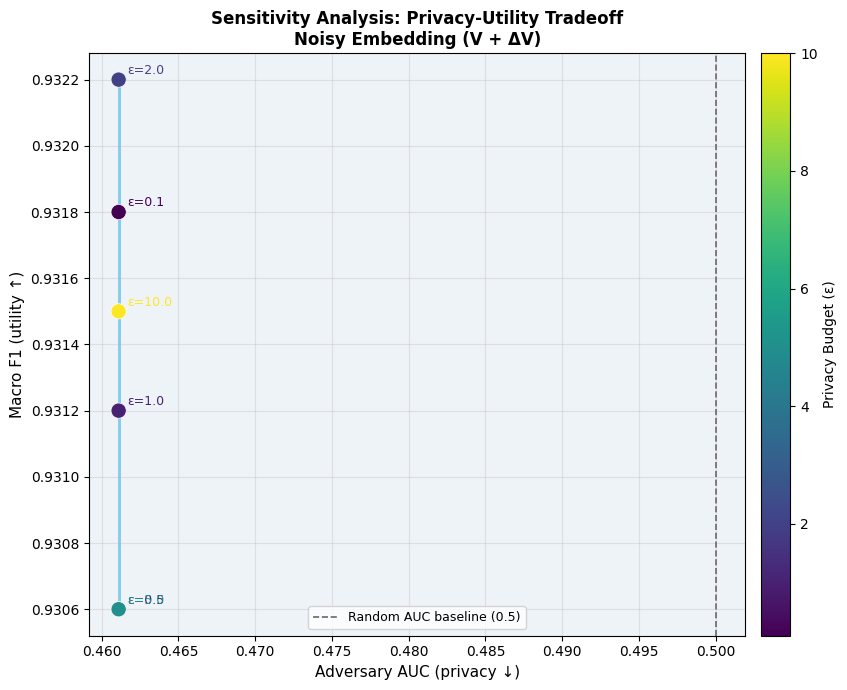

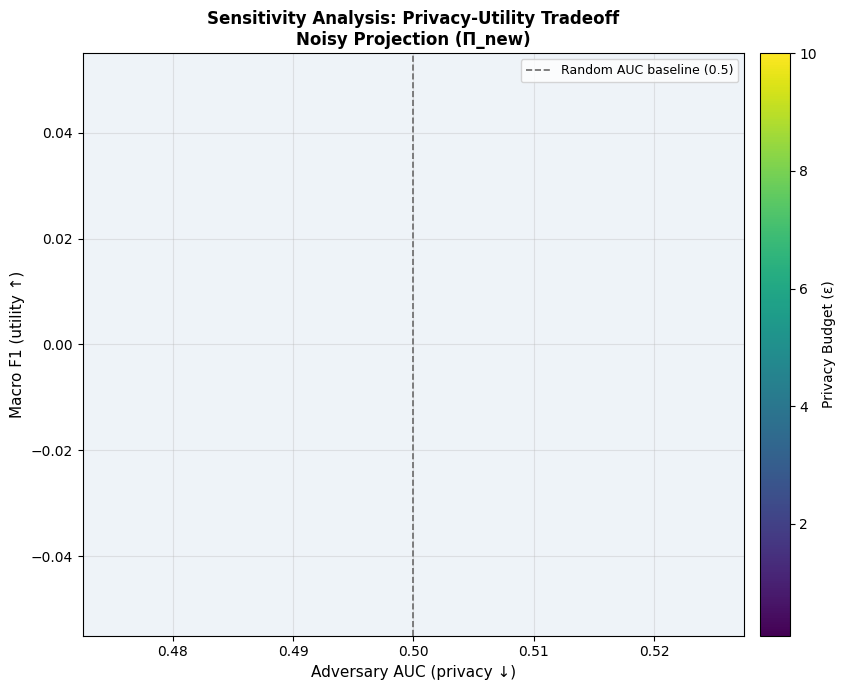

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

cmap    = cm.viridis
eps_arr = np.array(epsilons)
norm    = mcolors.Normalize(vmin=eps_arr.min(), vmax=eps_arr.max())

stage_titles = {
    "Noisy Embedding" : "Noisy Embedding (V + ΔV)",
    "Noisy Projection": "Noisy Projection (Π_new)",
}

baseline = max((y == sensitive_label).mean(), 1 - (y == sensitive_label).mean())

for stage, recs in records.items():
    adv_aucs = [r["adv_auc"]  for r in recs]
    f1s      = [r["macro_f1"] for r in recs]
    eps_vals = [r["epsilon"]  for r in recs]
    colors   = [cmap(norm(e)) for e in eps_vals]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_facecolor("#EEF3F8")
    fig.patch.set_facecolor("white")

    ax.plot(adv_aucs, f1s, color="skyblue", linewidth=1.8, zorder=1)
    sc = ax.scatter(adv_aucs, f1s, c=eps_vals, cmap=cmap, norm=norm,
                    s=120, zorder=2, edgecolors="white", linewidths=0.5)

    for r, c in zip(recs, colors):
        ax.annotate(
            f"ε={r['epsilon']}",
            xy=(r["adv_auc"], r["macro_f1"]),
            xytext=(6, 4), textcoords="offset points",
            fontsize=9, color=c,
        )

    ax.axvline(0.5, color="dimgray", linestyle="--", linewidth=1.2,
               label="Random AUC baseline (0.5)")

    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("Privacy Budget (ε)", fontsize=10)

    ax.set_xlabel("Adversary AUC (privacy ↓)", fontsize=11)
    ax.set_ylabel("Macro F1 (utility ↑)", fontsize=11)
    ax.set_title(
        f"Sensitivity Analysis: Privacy-Utility Tradeoff\n{stage_titles[stage]}",
        fontsize=12, fontweight="bold",
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()